<a href="https://colab.research.google.com/github/UROOJKHANdev/ARTIFICIAL_INTELLIGENCE-AND-DATA-SCIENCE-MODELS-/blob/main/HIERARCHICAL_CLUSTERING_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.shape

(440, 8)

In [4]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


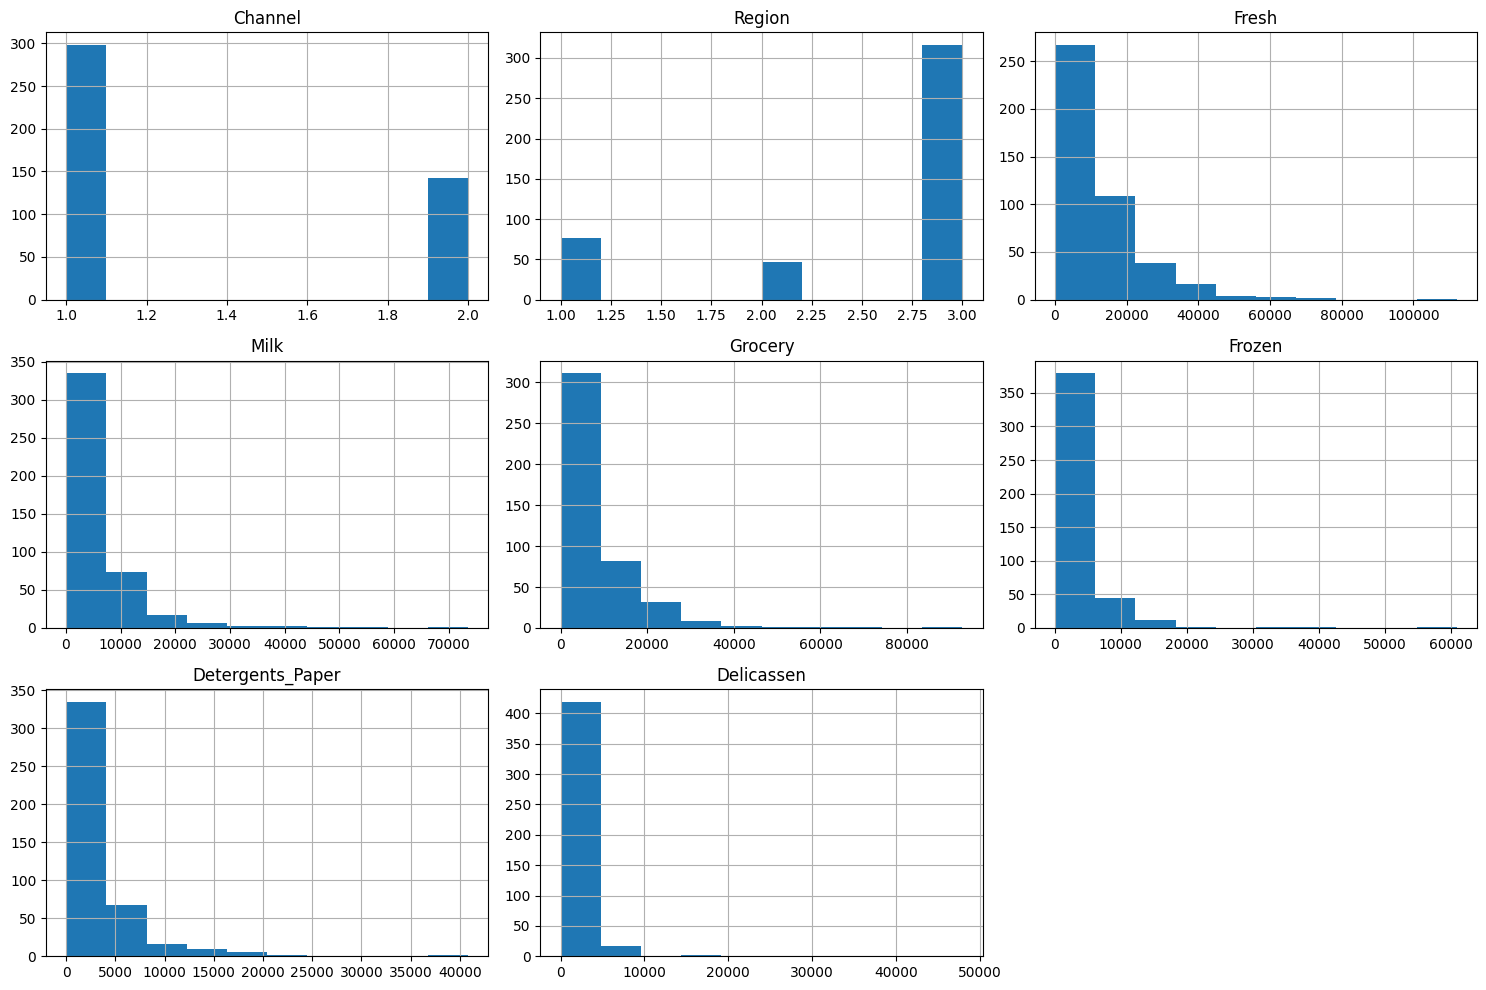

In [10]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

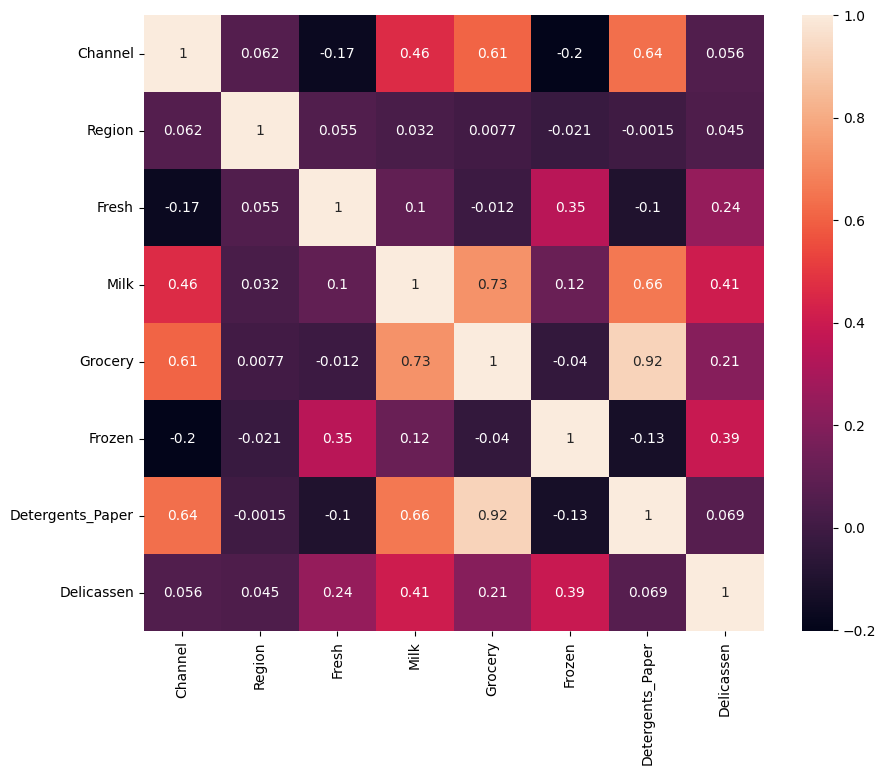

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

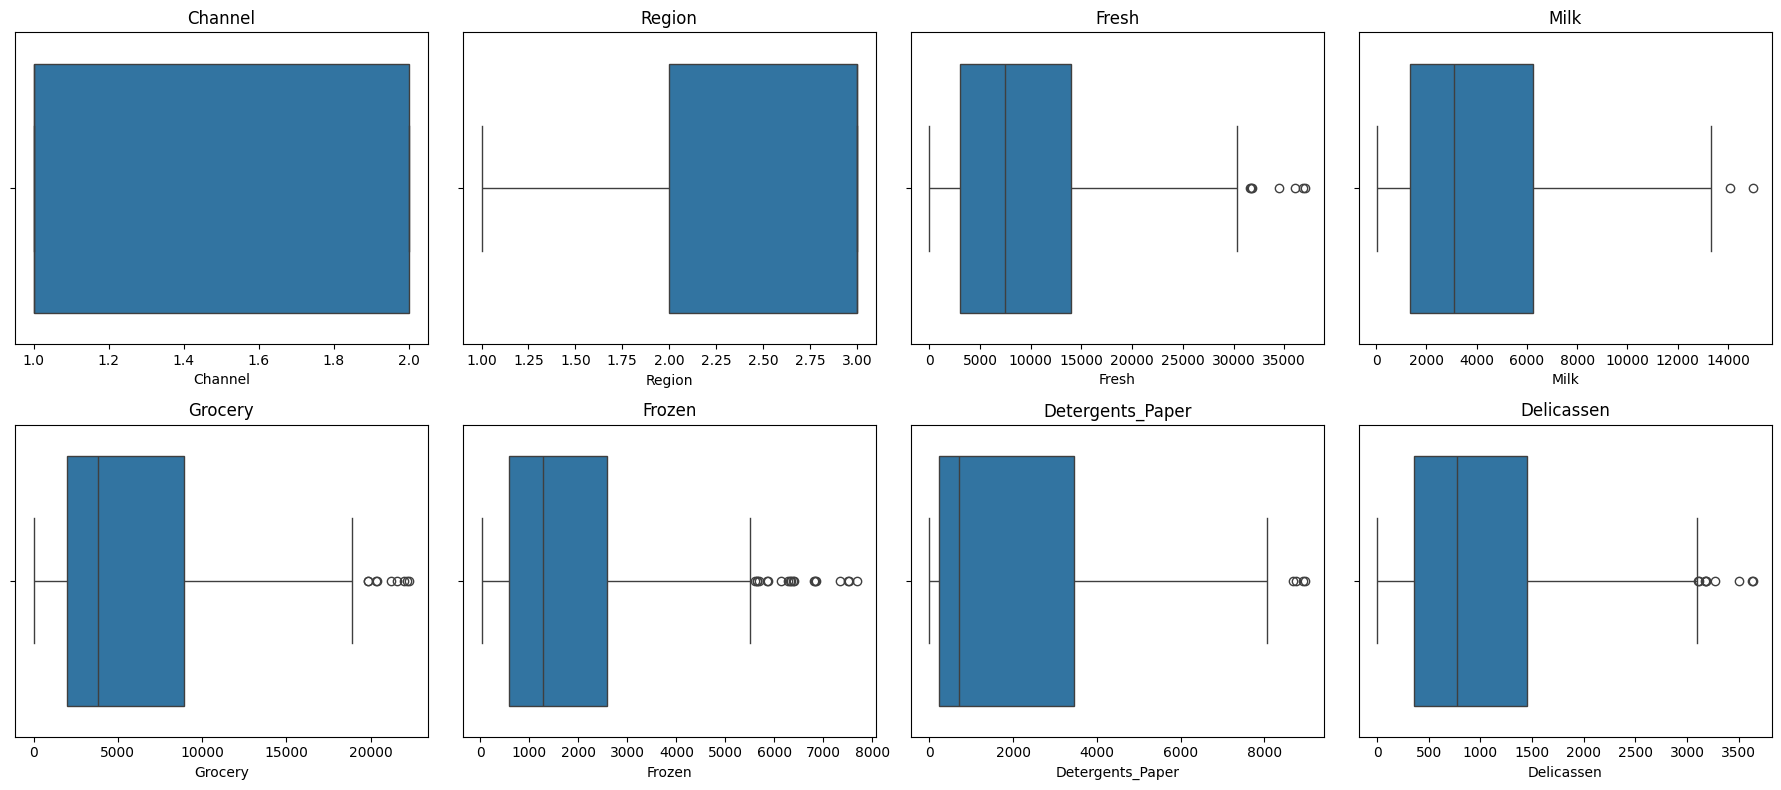

In [16]:
plt.figure(figsize=(18,8))

for i, col in enumerate(df.columns, 1):

    plt.subplot(2,4,i)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [17]:
columns = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    ~((df[columns] < lower) | (df[columns] > upper)).any(axis=1)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (286, 8)


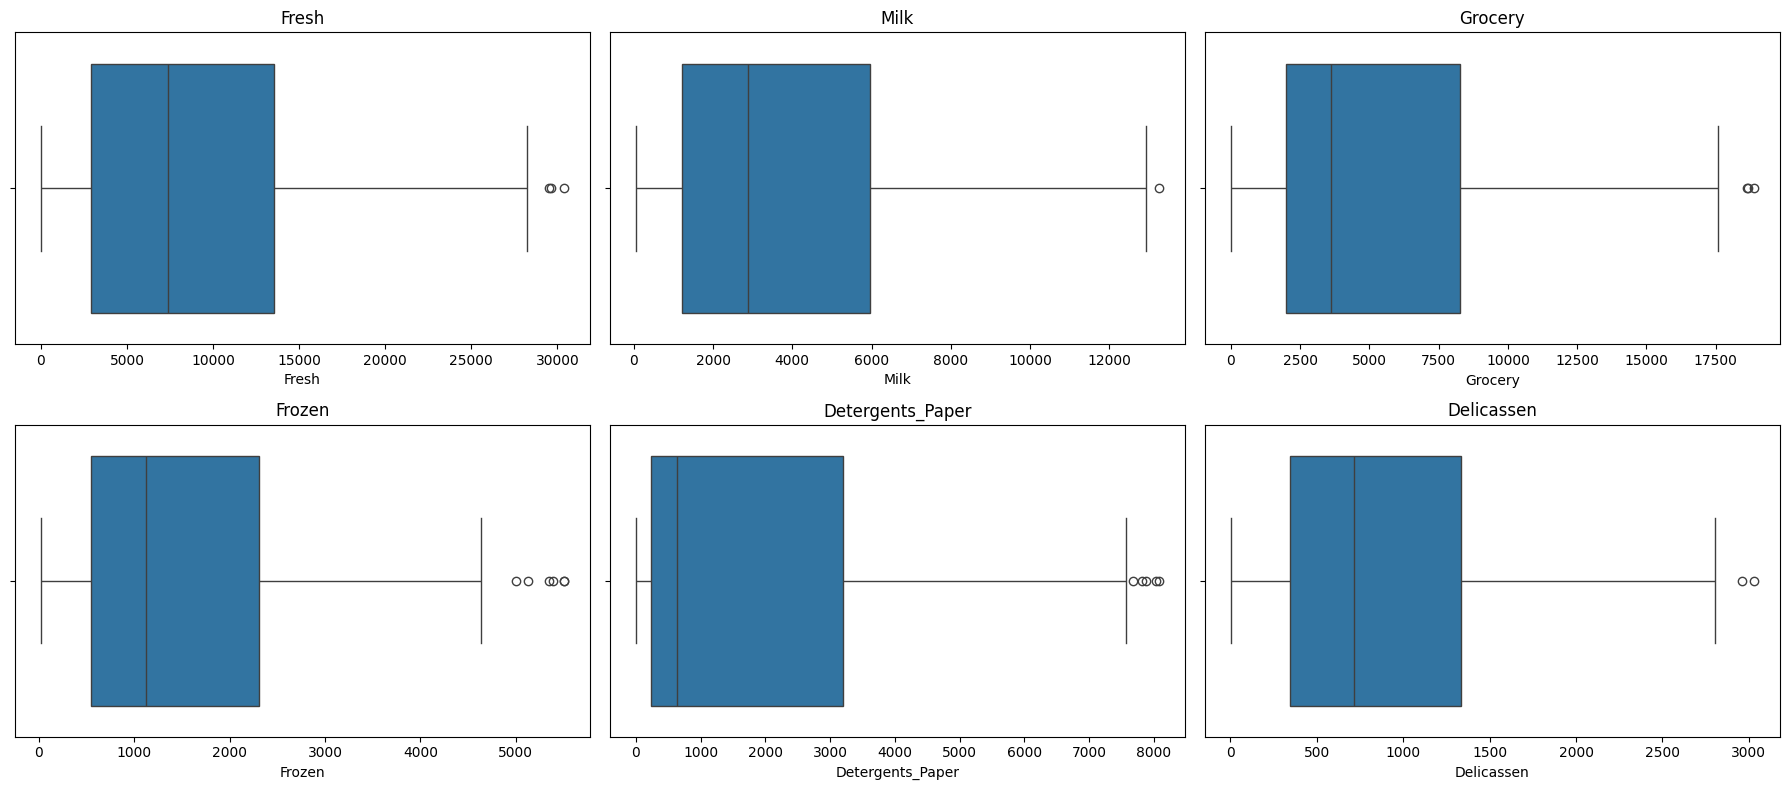

In [18]:
plt.figure(figsize=(18,8))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

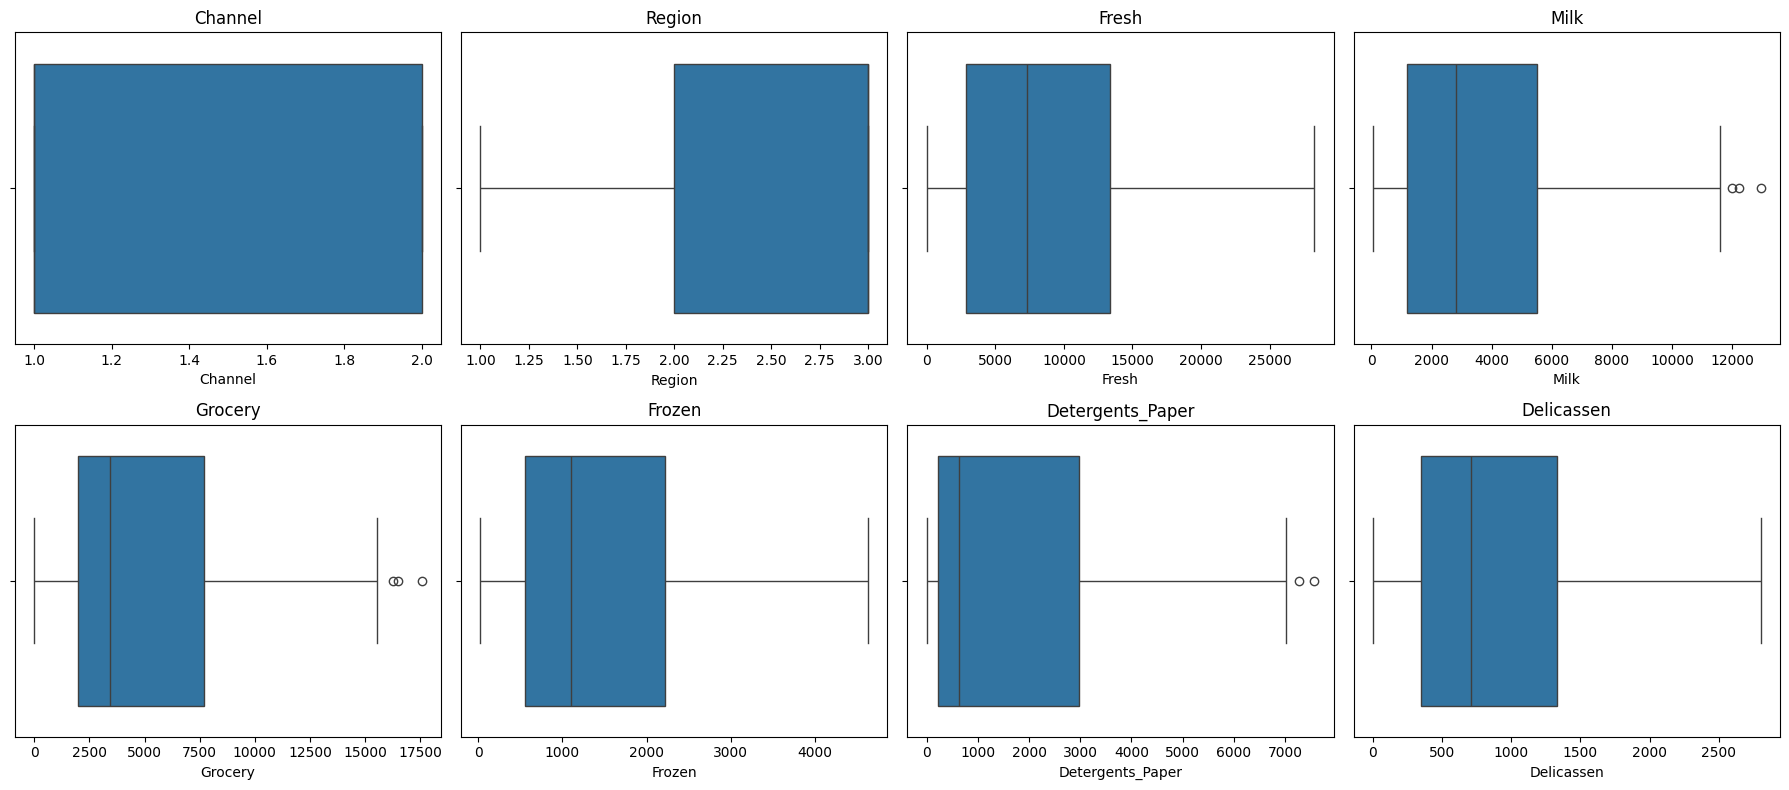

In [20]:
# SECOND TIME OUTLIER CHECK
plt.figure(figsize=(18,8))

for i, col in enumerate(df.columns, 1):

    plt.subplot(2,4,i)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [21]:
columns = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    ~((df[columns] < lower) | (df[columns] > upper)).any(axis=1)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (261, 8)


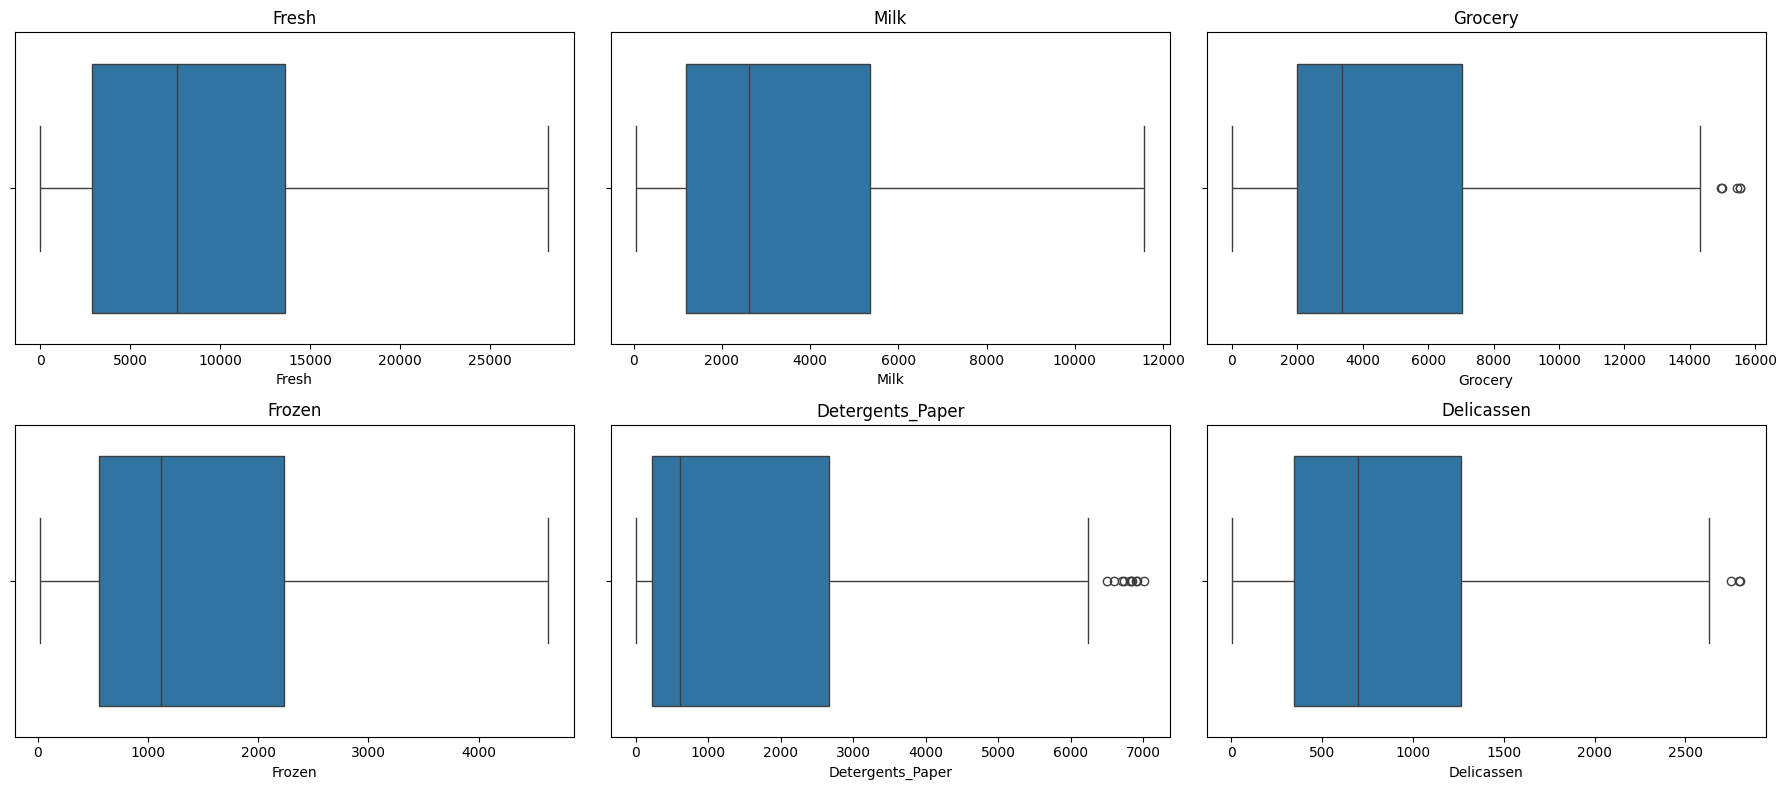

In [22]:
plt.figure(figsize=(18,8))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

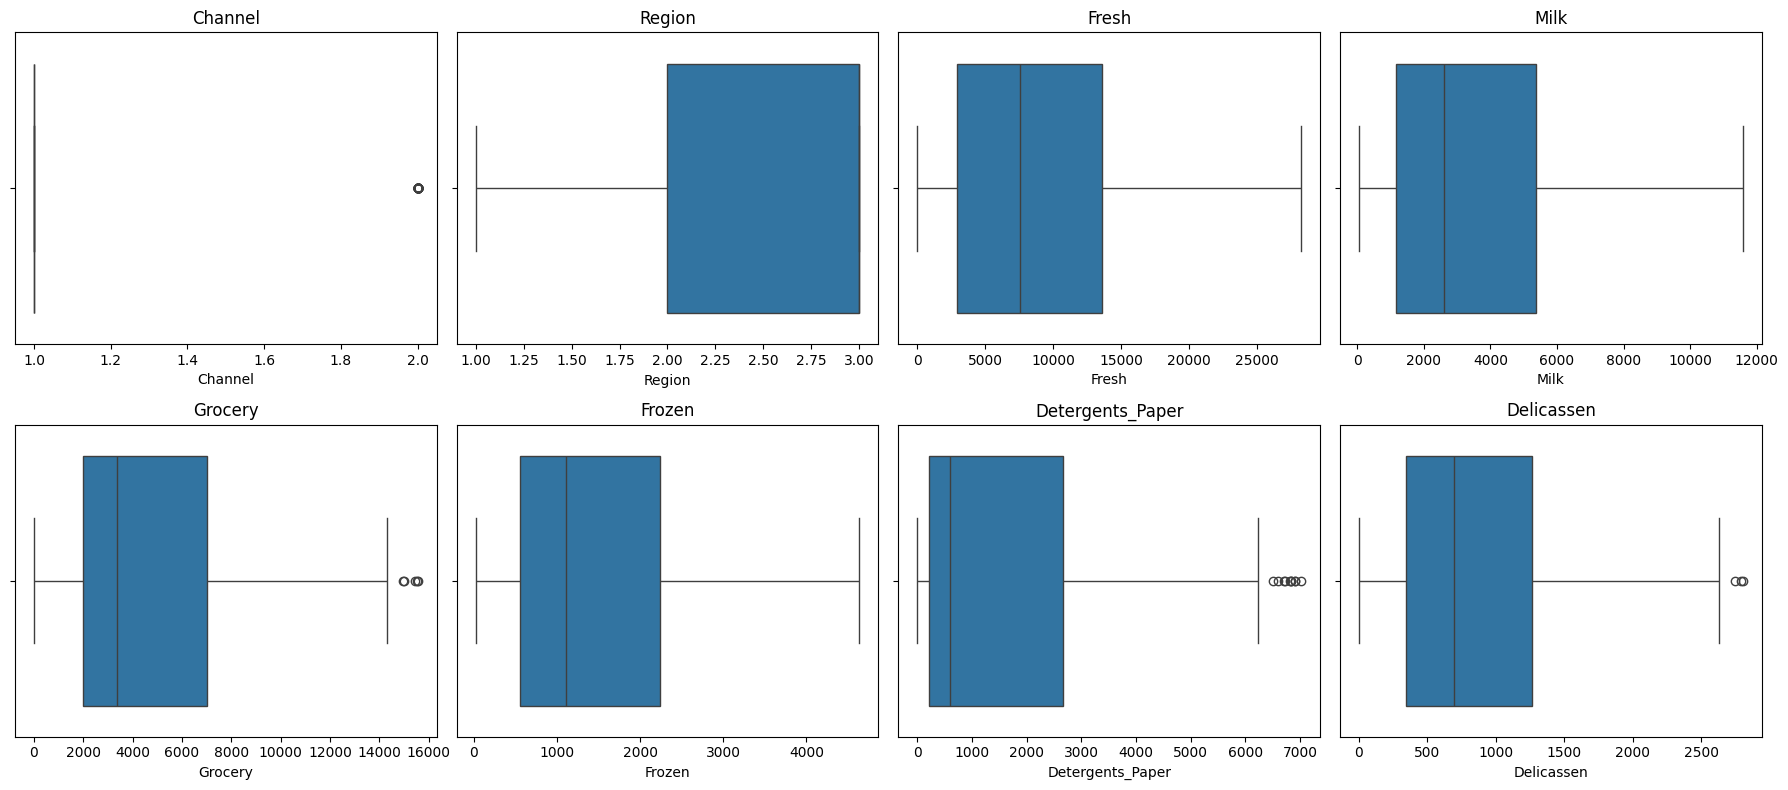

In [23]:
# THIRD TIME OUTLIER CHECK
plt.figure(figsize=(18,8))

for i, col in enumerate(df.columns, 1):

    plt.subplot(2,4,i)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [24]:
columns = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    ~((df[columns] < lower) | (df[columns] > upper)).any(axis=1)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (246, 8)


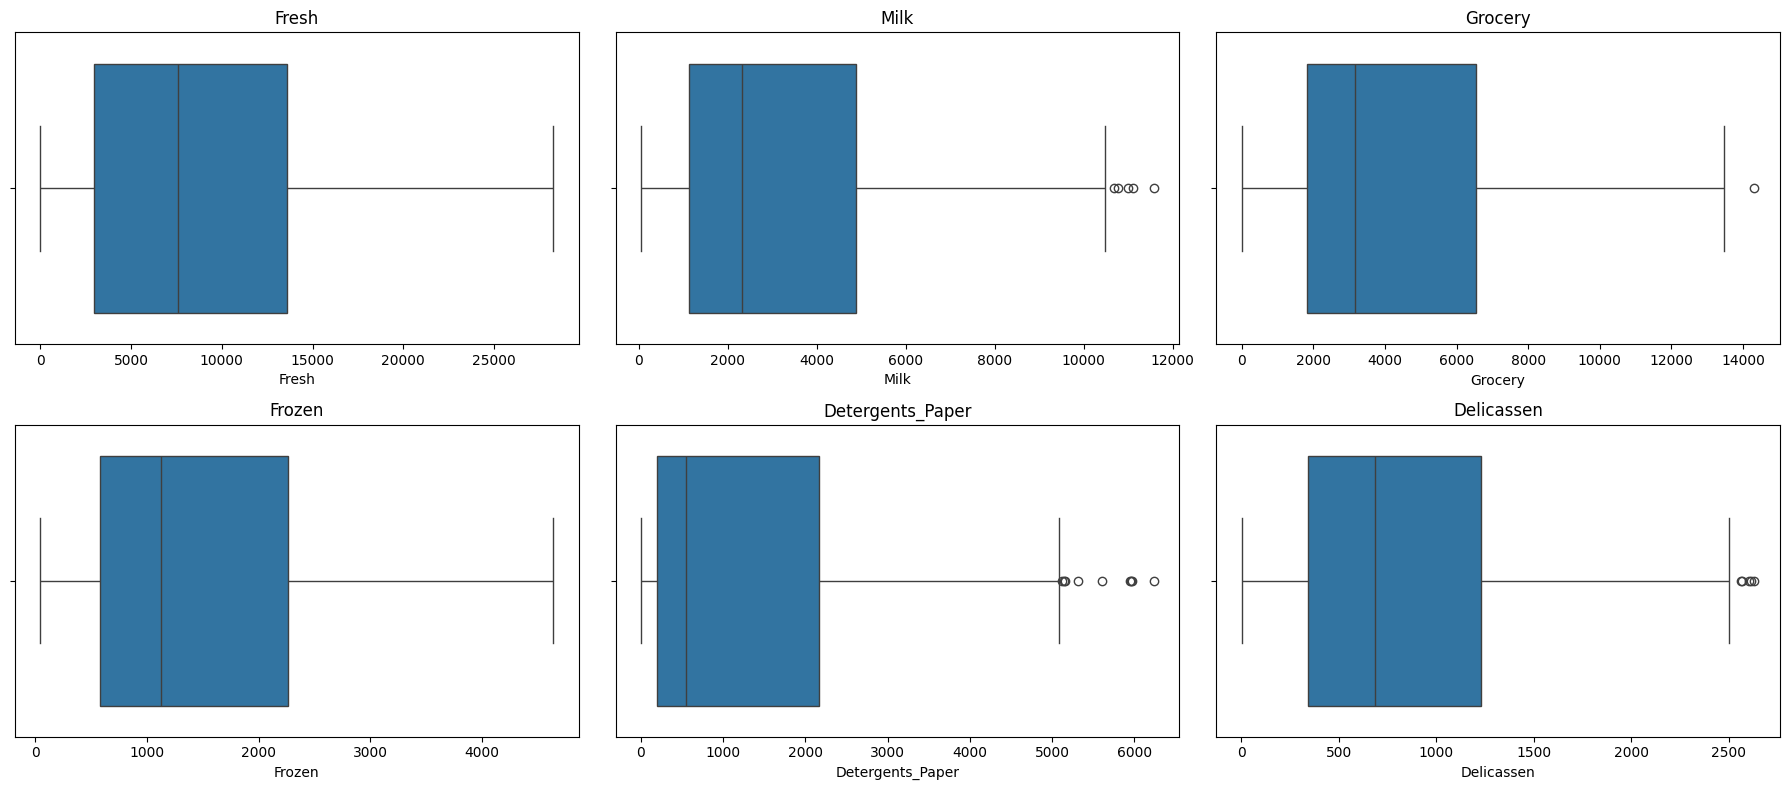

In [25]:
plt.figure(figsize=(18,8))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

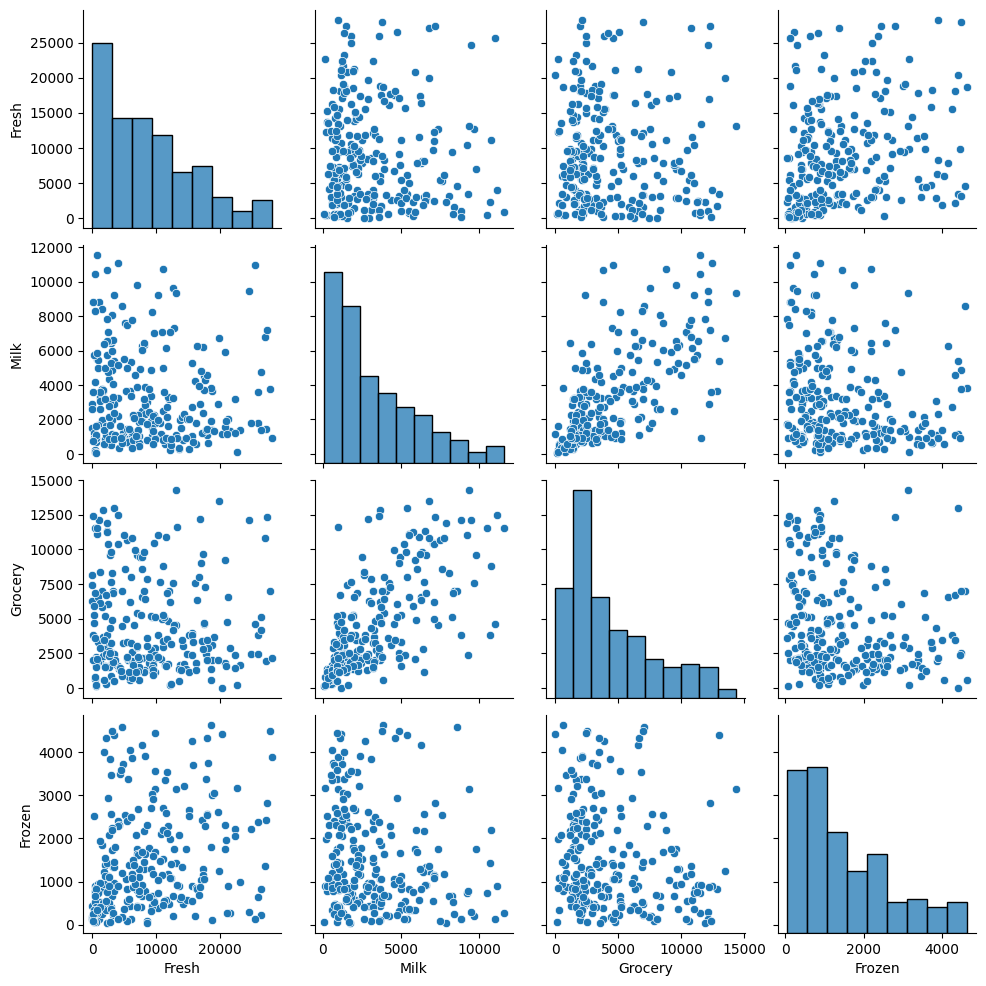

In [26]:
sns.pairplot(
    df[['Fresh',
        'Milk',
        'Grocery',
        'Frozen']]
)

plt.show()

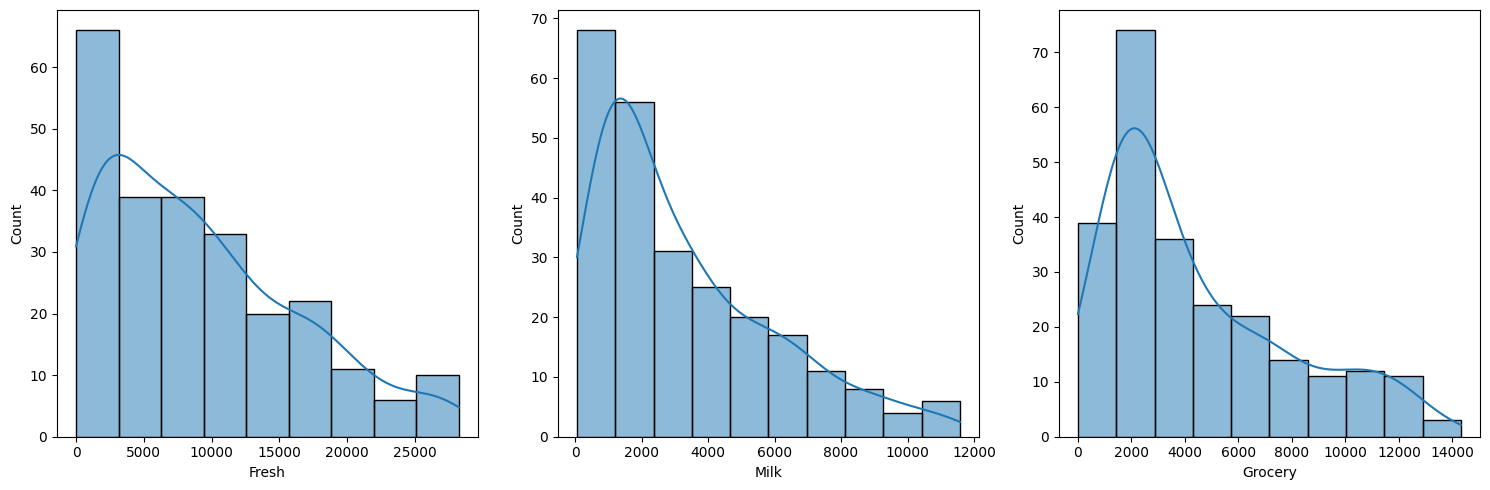

In [27]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['Fresh'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Milk'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Grocery'], kde=True)

plt.tight_layout()

plt.show()

In [28]:
X = df.copy()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(246, 8)


In [30]:
X_scaled[:5]

array([[ 1.95538472,  0.60018882,  0.49326622,  2.38551308,  0.90618115,
        -1.09623258,  0.82008232,  0.71119791],
       [ 1.95538472,  0.60018882, -0.28626132,  2.44315462,  1.48866928,
         0.21229032,  1.20358947,  1.37486929],
       [ 1.95538472,  0.60018882,  0.04099579,  1.86262192,  0.19947531,
        -0.71415742,  0.27548977,  0.88241906],
       [ 1.95538472,  0.60018882,  0.41784151, -0.03131456,  0.73610738,
        -0.87138304,  1.10879691, -0.49038064],
       [ 1.95538472,  0.60018882, -0.21375359,  0.62632307,  1.44745687,
         0.13367751,  1.22093712,  2.57190214]])

In [31]:
model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

print(model)

AgglomerativeClustering(n_clusters=3)


In [32]:
clusters = model.fit_predict(X_scaled)

print(clusters)

[1 1 1 1 1 0 1 1 1 0 1 0 1 2 1 2 2 0 2 0 1 1 1 2 0 1 2 0 2 0 1 1 2 0 1 0 1
 2 2 0 0 1 2 1 2 0 1 0 0 1 2 2 1 2 2 2 2 2 0 2 2 2 2 1 0 0 2 0 0 0 1 0 0 2
 2 0 2 2 2 0 2 0 0 2 1 1 0 2 1 0 0 2 0 2 1 2 0 2 0 0 2 1 2 0 0 1 2 0 0 0 0
 1 0 2 0 0 1 2 0 0 0 0 0 1 0 0 0 2 0 2 0 0 2 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0
 0 0 0 2 1 0 1 0 2 0 2 2 1 2 1 2 1 1 0 1 1 2 0 2 0 2 0 2 0 2 2 0 2 2 0 2 2
 1 2 1 0 2 0 1 2 2 0 0 2 0 2 0 0 0 0 0 0 2 0 2 0 0 1 2 2 2 0 2 2 2 0 0 2 2
 2 2 2 2 2 2 1 0 0 1 0 0 1 2 1 1 1 0 0 2 0 0 0 0]


In [33]:
df['Cluster'] = clusters

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
5        2       3   9413  8259     5126     666              1795   
6        2       3  12126  3199     6975     480              3140   
7        2       3   7579  4956     9426    1669              3321   

   Delicassen  Cluster  
0        1338        1  
1        1776        1  
5        1451        1  
6         545        1  
7        2566        1  


In [34]:
print(df['Cluster'].value_counts())

Cluster
0    104
2     89
1     53
Name: count, dtype: int64


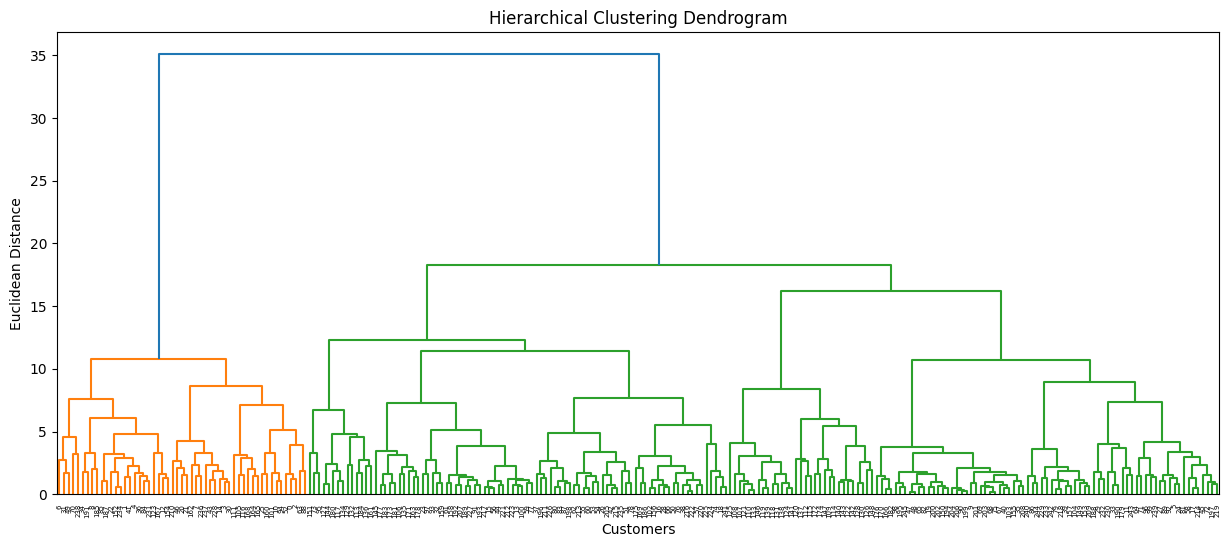

In [35]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(15,6))

linked = linkage(X_scaled, method='ward')

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

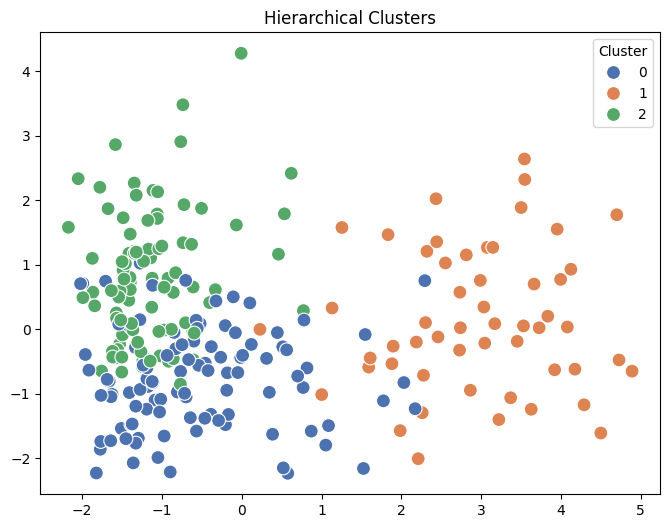

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Hierarchical Clusters")

plt.show()

In [37]:
print(df.groupby('Cluster').mean())

          Channel    Region         Fresh         Milk      Grocery  \
Cluster                                                               
0        1.000000  2.375000   5002.644231  2902.451923  3486.826923   
1        1.962264  2.716981   9288.075472  6285.528302  9184.377358   
2        1.000000  2.606742  13825.292135  1938.730337  2724.910112   

              Frozen  Detergents_Paper   Delicassen  
Cluster                                              
0         893.990385        891.278846   712.394231  
1        1256.547170       3742.433962  1153.433962  
2        2383.134831        462.280899   881.606742  


In [38]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.18169321761663124


In [39]:
from sklearn.metrics import davies_bouldin_score

db = davies_bouldin_score(X_scaled, clusters)

print("Davies-Bouldin Index:", db)

Davies-Bouldin Index: 1.8137348048949729


In [40]:
from sklearn.metrics import calinski_harabasz_score

ch = calinski_harabasz_score(X_scaled, clusters)

print("Calinski-Harabasz Score:", ch)

Calinski-Harabasz Score: 80.29587957402894


In [41]:
print(df[['Cluster']].head(10))

    Cluster
0         1
1         1
5         1
6         1
7         1
8         0
10        1
11        1
14        1
15        0


In [42]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

scores = {}

for k in range(2, 8):

    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores[k] = score

print(scores)

{2: np.float64(0.3654998055801538), 3: np.float64(0.18169321761663124), 4: np.float64(0.19390778043517706), 5: np.float64(0.20078544847246513), 6: np.float64(0.1956867091149151), 7: np.float64(0.17043908501917016)}


In [43]:
best_k = max(scores, key=scores.get)

print("Best Number of Clusters:", best_k)

Best Number of Clusters: 2


In [44]:
final_model = AgglomerativeClustering(
    n_clusters=best_k,
    metric='euclidean',
    linkage='ward'
)

clusters = final_model.fit_predict(X_scaled)

df['Cluster'] = clusters

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AgglomerativeClustering(
        n_clusters=best_k,
        metric='euclidean',
        linkage='ward'
    ))
])

pipeline.fit(df.drop('Cluster', axis=1))

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', AgglomerativeClustering())])

In [46]:
df.to_csv("Wholesale_Customers_Clustered.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [47]:
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
5        2       3   9413  8259     5126     666              1795   
6        2       3  12126  3199     6975     480              3140   
7        2       3   7579  4956     9426    1669              3321   

   Delicassen  Cluster  
0        1338        1  
1        1776        1  
5        1451        1  
6         545        1  
7        2566        1  


In [48]:
print(df['Cluster'].value_counts())

Cluster
0    193
1     53
Name: count, dtype: int64


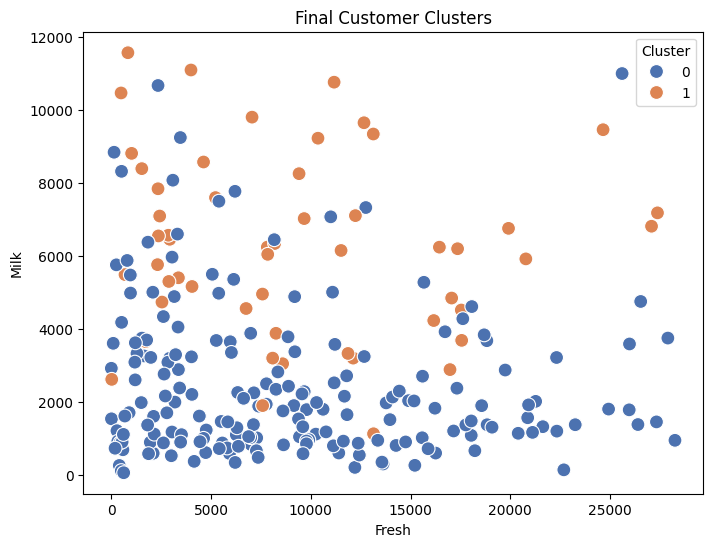

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Fresh'],
    y=df['Milk'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Final Customer Clusters")

plt.show()

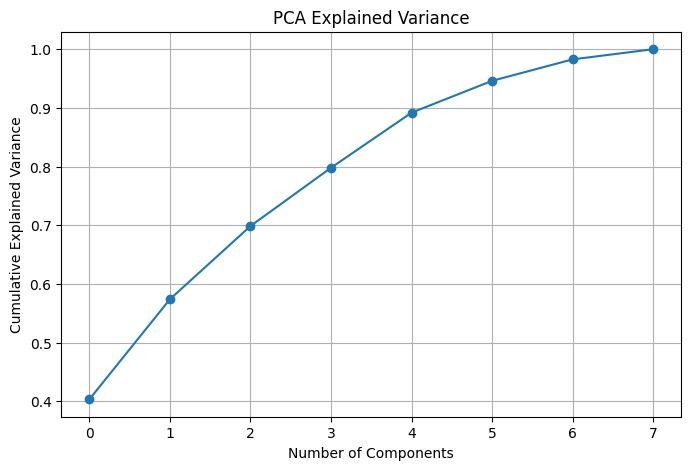

In [50]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()

pca.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

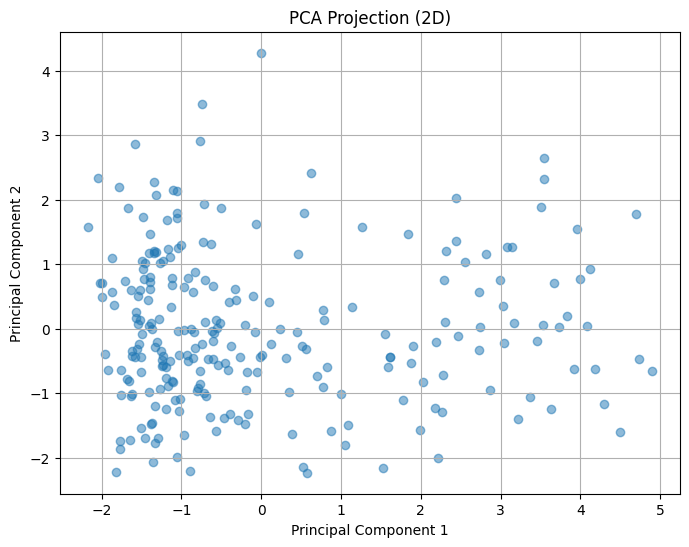

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(X_pca_2[:,0], X_pca_2[:,1], alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection (2D)")

plt.grid(True)

plt.show()

In [52]:
from sklearn.metrics import silhouette_score

score_pca = silhouette_score(X_pca_2, clusters)

print("Silhouette Score (PCA):", score_pca)

Silhouette Score (PCA): 0.5285410944851862
